<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_5/enc_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontro 5: Estatística descritiva e visualização de distribuições

**Instrutor:** Jhonatan Lopes

A demonstração com Datasaurus estabeleceu um princípio que orientará a parte
estatística do curso: resumos numéricos devem ser interpretados em relação à
estrutura e à distribuição dos dados.

Neste notebook, aplicamos esse princípio a uma variável quantitativa discreta
extraída de um conjunto de artigos do arXiv. A análise combina inspeção
numérica e representação gráfica para examinar centro, dispersão e forma da
distribuição.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Estrutura do conjunto de dados

Cada linha do conjunto representa um artigo. As colunas registram informações
bibliográficas, categorias atribuídas no arXiv e algumas contagens derivadas do
texto e dos metadados.

Entre as variáveis disponíveis estão:

- identificadores e informações textuais, como `paper_id`, `title` e
  `abstract_preview`;
- categorias do arXiv, como `primary_category` e `top_level`;
- informações temporais, como `year` e `decade`;
- contagens, como `n_authors`, `n_versions`, `n_categories`,
  `title_n_words` e `abstract_n_words`;
- indicadores Booleanos, como `has_doi` e `has_journal_ref`.

A unidade de observação permanece o artigo em todas as análises deste notebook.

In [3]:
arxiv_url = (
    "https://raw.githubusercontent.com/jhlopesalves/"
    "eda_humanidades/refs/heads/main/"
    "encontro_5/data/arxiv_eda_papers.csv"
)

arxiv_df = pd.read_csv(
    arxiv_url,
    dtype={"paper_id": "string"},
)

In [4]:
arxiv_df.head()

,paper_id,title,abstract_preview,primary_category,category_label,top_level,top_level_label,year,decade,n_authors,n_versions,n_categories,title_n_words,abstract_n_words,has_doi,has_journal_ref
0,2001.04171,Multi-Sensor Data and Knowledge Fusion -- A Pr...,Fusion is a common tool for the analysis and u...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,1,3,12,108,False,False
1,2001.04417,Maximal Closed Set and Half-Space Separations ...,Several concept learning problems can be regar...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,3,3,2,10,170,False,False
2,2002.00509,A Machine Consciousness architecture based on ...,Recent developments in machine learning have p...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,2,1,11,197,False,False
3,2003.03875,Overview of the CCKS 2019 Knowledge Graph Eval...,Knowledge graph models world knowledge as conc...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,25,1,2,14,92,False,False
4,2003.06492,On Sufficient and Necessary Conditions in Boun...,Computation Tree Logic (CTL) is one of the cen...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,5,3,2,11,203,False,False


In [5]:
arxiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   paper_id          3387 non-null   string
 1   title             3387 non-null   str   
 2   abstract_preview  3387 non-null   str   
 3   primary_category  3387 non-null   str   
 4   category_label    3387 non-null   str   
 5   top_level         3387 non-null   str   
 6   top_level_label   3387 non-null   str   
 7   year              3387 non-null   int64 
 8   decade            3387 non-null   str   
 9   n_authors         3387 non-null   int64 
 10  n_versions        3387 non-null   int64 
 11  n_categories      3387 non-null   int64 
 12  title_n_words     3387 non-null   int64 
 13  abstract_n_words  3387 non-null   int64 
 14  has_doi           3387 non-null   bool  
 15  has_journal_ref   3387 non-null   bool  
dtypes: bool(2), int64(6), str(7), string(1)
memory usage: 377.2 KB


In [6]:
arxiv_df.describe()

,year,n_authors,n_versions,n_categories,title_n_words,abstract_n_words
count,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000
mean,2022.854739,4.202834,1.695010,2.184529,9.912902,172.085326
std,1.732267,4.305577,0.992284,1.113424,3.524000,47.876997
min,2020.000000,1.000000,1.000000,1.000000,2.000000,38.000000
25%,2021.000000,2.000000,1.000000,1.000000,7.000000,139.000000
50%,2023.000000,4.000000,1.000000,2.000000,10.000000,171.000000
75%,2024.000000,5.000000,2.000000,3.000000,12.000000,204.000000
max,2025.000000,182.000000,8.000000,8.000000,32.000000,310.000000


`describe()` identifica as colunas numericamente representadas e calcula para
elas contagem, média, desvio-padrão, mínimo, quartis e máximo.

A representação numérica de uma coluna não determina sua interpretação
estatística. `year`, por exemplo, é armazenada como inteiro, mas representa uma
posição temporal; `n_authors`, `n_versions` e `n_categories` são contagens.

Os resumos produzidos automaticamente devem, portanto, ser interpretados em
relação ao significado de cada variável.

In [7]:
arxiv_df = arxiv_df.astype(
    {
        "title": "string",
        "abstract_preview": "string",
        "primary_category": "category",
        "category_label": "category",
        "top_level": "category",
        "top_level_label": "category",
        "decade": "category",
        "has_doi": "bool",
        "has_journal_ref": "bool",
    }
)

arxiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   paper_id          3387 non-null   string  
 1   title             3387 non-null   string  
 2   abstract_preview  3387 non-null   string  
 3   primary_category  3387 non-null   category
 4   category_label    3387 non-null   category
 5   top_level         3387 non-null   category
 6   top_level_label   3387 non-null   category
 7   year              3387 non-null   int64   
 8   decade            3387 non-null   category
 9   n_authors         3387 non-null   int64   
 10  n_versions        3387 non-null   int64   
 11  n_categories      3387 non-null   int64   
 12  title_n_words     3387 non-null   int64   
 13  abstract_n_words  3387 non-null   int64   
 14  has_doi           3387 non-null   bool    
 15  has_journal_ref   3387 non-null   bool    
dtypes: bool(2), category(5), int64(6), 

## 2. Distribuição de `n_categories`

A variável `n_categories` registra o número de categorias do arXiv associadas a
cada artigo.

Trata-se de uma **variável quantitativa discreta**: cada observação assume um
valor inteiro correspondente a uma contagem de categorias.

Examinaremos inicialmente seu resumo numérico e, em seguida, sua distribuição.

In [8]:
arxiv_df["n_categories"].describe()

count    3387.000000
mean        2.184529
std         1.113424
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: n_categories, dtype: float64

Há 3.387 artigos. O número médio de categorias é aproximadamente `2.18`, e a
médiana é `2`. Metade das observações encontra-se entre `1` e `3` categorias,
enquanto o valor máximo observado é `8`.

Esses valores descrevem localização e amplitude da variável, mas ainda não
mostram como as 3.387 observações se distribuem entre os valores possíveis.

## 3. Centro, dispersão e forma da distribuição

Uma medida de centro resume a localização dos valores observados. Sua
interpretação exige também informação sobre a variabilidade e a forma da
distribuição.

Uma descrição estatística deve considerar conjuntamente onde os valores se
concentram, quanto variam e como se distribuem ao longo da escala.

Para `n_categories`, examinaremos cinco aspectos:

1. onde se localiza o centro da distribuição;
2. qual é a magnitude da variação entre as observações;
3. como os valores se distribuem ao longo da escala;
4. se há assimetria, concentrações ou valores extremos;
5. como os resumos numéricos correspondem à representação gráfica.

Essas perguntas orientarão a escolha e a interpretação das medidas utilizadas
a seguir.

### 3.1 Desvio-padrão

O desvio-padrão quantifica a dispersão das observações em torno da média. Na
forma utilizada por padrão em pandas, o cálculo é:

$$
s
=
\sqrt{
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})^2
}{
n-1
}
}
$$

em que $x_i$ representa cada observação, $\bar{x}$ a média e $n$ o número de
observações.

O cálculo utiliza as distâncias entre cada valor e a média. Essas diferenças
são elevadas ao quadrado, somadas, divididas por $n-1$ e, por fim, convertidas
novamente à escala original pela raiz quadrada.

Como os desvios são elevados ao quadrado, observações mais distantes da média
recebem peso crescente no cálculo. O desvio-padrão é, portanto, sensível a
valores extremos.

Neste notebook, utilizaremos o denominador $n-1$ para manter a mesma convenção
de `Series.std()` e de `describe()` em pandas.

### Cálculo explícito do desvio-padrão

A fórmula pode ser decomposta nas mesmas operações que aparecem em sua
notação matemática. Primeiro calculamos a média; em seguida, os desvios
quadráticos de cada observação; depois, a variância; por fim, sua raiz
quadrada.

In [9]:
values = arxiv_df["n_categories"]

x_bar = values.mean()
n = len(values)

squared_deviations = []

for x_i in values:
    squared_deviation = (x_i - x_bar) ** 2
    squared_deviations.append(squared_deviation)

sum_of_squared_deviations = np.sum(squared_deviations)

sample_variance = sum_of_squared_deviations / (n - 1)
sample_standard_deviation = np.sqrt(sample_variance)

print(f"Média: {x_bar:.3f}")
print(f"Soma dos desvios quadráticos: {sum_of_squared_deviations:.3f}")
print(f"Variância: {sample_variance:.3f}")
print(f"Desvio-padrão: {sample_standard_deviation:.3f}")

Média: 2.185
Soma dos desvios quadráticos: 4197.669
Variância: 1.240
Desvio-padrão: 1.113


A variância corresponde à etapa anterior à raiz quadrada e, por isso, é
expressa na unidade original elevada ao quadrado. O desvio-padrão retorna à
mesma unidade da variável analisada.

Para `n_categories`, o desvio-padrão é expresso em número de categorias. Essa
propriedade facilita sua interpretação em relação à escala observada.

In [10]:
var_categories = arxiv_df["n_categories"].var(ddof=1)
std_categories = arxiv_df["n_categories"].std(ddof=1)

print(f"Variância com pandas: {var_categories:.3f}")
print(f"Desvio-padrão com pandas: {std_categories:.3f}")

Variância com pandas: 1.240
Desvio-padrão com pandas: 1.113


A média e o desvio-padrão resumem, respectivamente, localização e dispersão em
dois valores escalares. A representação gráfica acrescenta informação sobre
como as observações se distribuem entre os valores possíveis de
`n_categories`.

Como `n_categories` é uma contagem inteira, essa estrutura discreta também deve
ser preservada na representação.

### Inspeção gráfica inicial

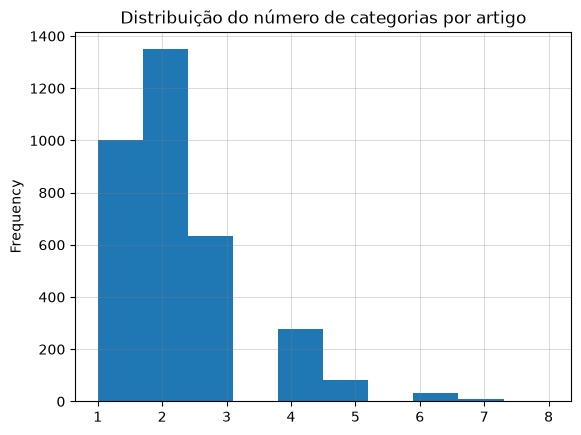

In [11]:
arxiv_df["n_categories"].plot(kind="hist")

plt.title("Distribuição do número de categorias por artigo")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")

plt.show()

### Histograma discreto com Seaborn

`n_categories` assume apenas valores inteiros. Em `sns.histplot()`,
`discrete=True` ajusta o histograma a essa estrutura, utilizando intervalos de
largura unitária centrados nos valores discretos.

O eixo vertical representa a frequência absoluta de artigos em cada valor de
`n_categories`.

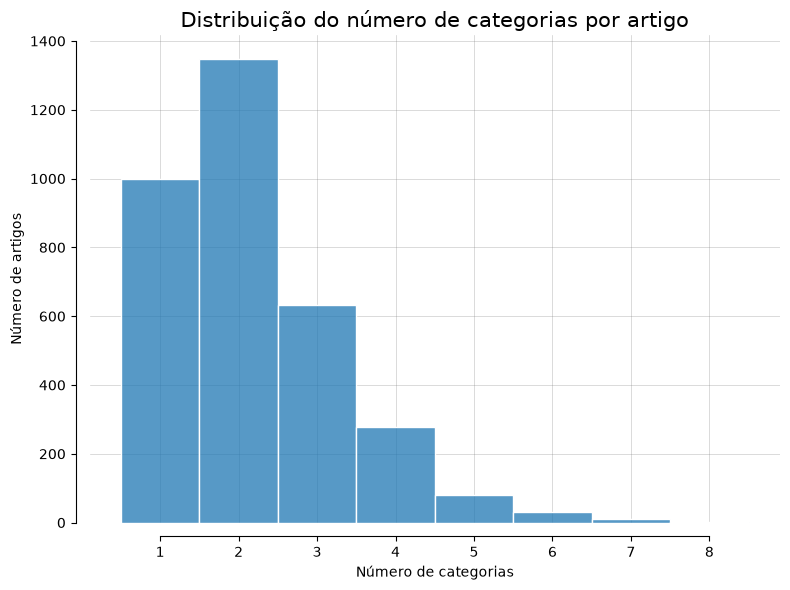

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=arxiv_df,
    x="n_categories",
    discrete=True,
    stat="count",
    edgecolor="white",
    ax=ax,
)

ax.set_title(
    "Distribuição do número de categorias por artigo",
    fontsize=15,
)

ax.set(
    xlabel="Número de categorias",
    ylabel="Número de artigos",
)

ax.set_axisbelow(True)
ax.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    trim=True,
    offset=10,
)

plt.tight_layout()
plt.show()

A distribuição concentra grande parte das observações nos menores números de
categorias e se estende até valores mais altos com frequência progressivamente
menor.

O terceiro quartil observado é `3`, enquanto o máximo é `8`. A representação
gráfica acrescenta a forma da distribuição aos resumos de centro e dispersão
calculados anteriormente.

### Sensibilidade à escolha dos intervalos

Um histograma representa a distribuição agrupando observações em intervalos.
A posição e a largura desses intervalos determinam quais valores contribuem
para cada barra e, por isso, influenciam a forma visual do gráfico.

O parâmetro `bins` controla essa divisão da escala. Diferentes escolhas podem
produzir representações visuais distintas a partir das mesmas observações.

Para variáveis contínuas, a escolha dos intervalos constitui uma decisão
analítica importante. Para `n_categories`, a questão é ainda mais explícita:
a variável assume apenas valores inteiros entre `1` e `8`. Intervalos que não
respeitam essa estrutura discreta podem introduzir barras vazias ou separações
sem significado substantivo.

Os três gráficos seguintes utilizam deliberadamente números diferentes de
intervalos sobre os mesmos dados.

#### 15 intervalos

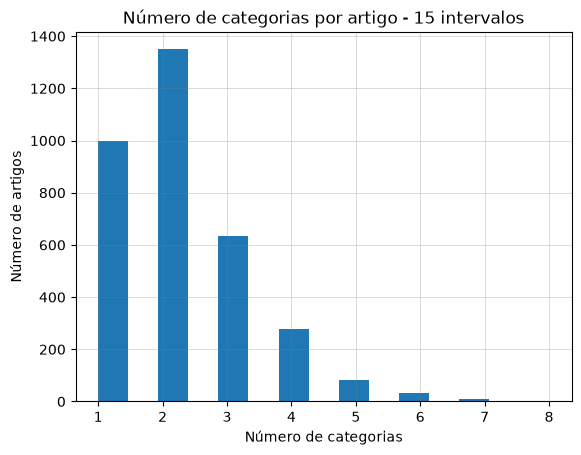

In [13]:
arxiv_df["n_categories"].plot(
    kind="hist",
    bins=15,
)

plt.title("Número de categorias por artigo - 15 intervalos")
plt.xlabel("Número de categorias")
plt.ylabel("Número de artigos")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")

plt.show()

#### 12 intervalos

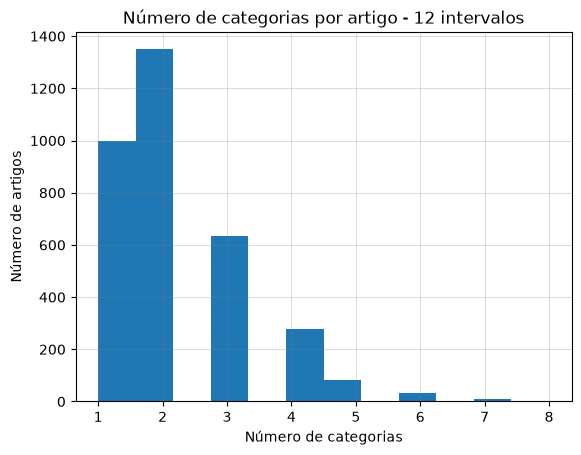

In [14]:
arxiv_df["n_categories"].plot(
    kind="hist",
    bins=12,
)

plt.title("Número de categorias por artigo - 12 intervalos")
plt.xlabel("Número de categorias")
plt.ylabel("Número de artigos")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")

plt.show()

#### 8 intervalos

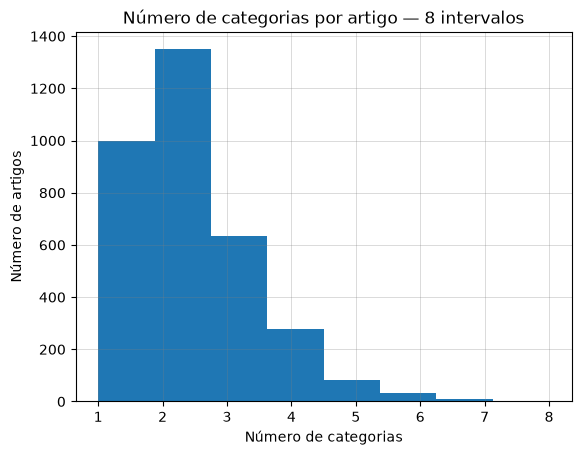

In [15]:
arxiv_df["n_categories"].plot(
    kind="hist",
    bins=8,
)

plt.title("Número de categorias por artigo — 8 intervalos")
plt.xlabel("Número de categorias")
plt.ylabel("Número de artigos")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")

plt.show()

Os três histogramas representam exatamente as mesmas 3.387 observações.
As diferenças visuais resultam exclusivamente da divisão da escala em
intervalos distintos.

Com `15` ou `12` intervalos, alguns intervalos ocupam regiões nas quais
`n_categories` não pode assumir valores, pois a variável é uma contagem
inteira. O gráfico passa, assim, a refletir parcialmente uma escolha de
representação que não corresponde à estrutura da variável.

Com `8` intervalos, a divisão se aproxima de uma barra para cada valor inteiro
observado, mas `discrete=True` continua sendo a especificação mais direta:
os intervalos são construídos explicitamente em torno dos valores discretos.

A escolha dos intervalos pertence à análise. Um histograma deve representar a
escala da variável de maneira compatível com os valores que ela pode assumir.

## 4. Distribuição normal como referência

A distribuição normal é uma distribuição contínua, simétrica e definida por
dois parâmetros: sua média e seu desvio-padrão.

Para estabelecer um contraste com `n_categories`, construiremos uma
distribuição normal com:

- média igual à média observada de `n_categories`;
- desvio-padrão igual ao desvio-padrão observado de `n_categories`;
- o mesmo número de observações do conjunto analisado.

A amostra simulada preservará aproximadamente esses valores de centro e
dispersão. Sua forma, porém, será determinada pela distribuição normal da qual
os valores são gerados.

`n_categories`, por sua vez, é uma contagem discreta observada entre `1` e `8`.
O contraste permite separar três propriedades que devem ser examinadas
distintamente: **centro, dispersão e forma da distribuição**.

In [16]:
mean_categories = arxiv_df["n_categories"].mean()
std_categories = arxiv_df["n_categories"].std(ddof=1)
n_articles = len(arxiv_df)

rng = np.random.default_rng(seed=42)

normal_df = pd.DataFrame(
    {
        "value": rng.normal(
            loc=mean_categories,
            scale=std_categories,
            size=n_articles,
        )
    }
)

normal_df.describe()

,value
count,3387.000000
mean,2.160591
std,1.113605
min,-1.877702
25%,1.423143
50%,2.186021
75%,2.892821
max,5.723942


### Propriedades da amostra simulada

A amostra simulada contém 3.387 observações geradas a partir de uma distribuição
normal com parâmetros definidos pela média e pelo desvio-padrão de
`n_categories`.

Como a geração é aleatória, a média e o desvio-padrão observados na simulação
aproximam os parâmetros especificados. A distribuição normal também produz
valores contínuos em toda a reta real; nesta realização, aparecem inclusive
valores negativos.

Esse suporte contrasta com `n_categories`, cuja escala consiste em contagens
inteiras e assume apenas valores positivos neste conjunto.

A comparação gráfica examinará, portanto, distribuições com centro e dispersão
semelhantes, mas com estruturas distintas.

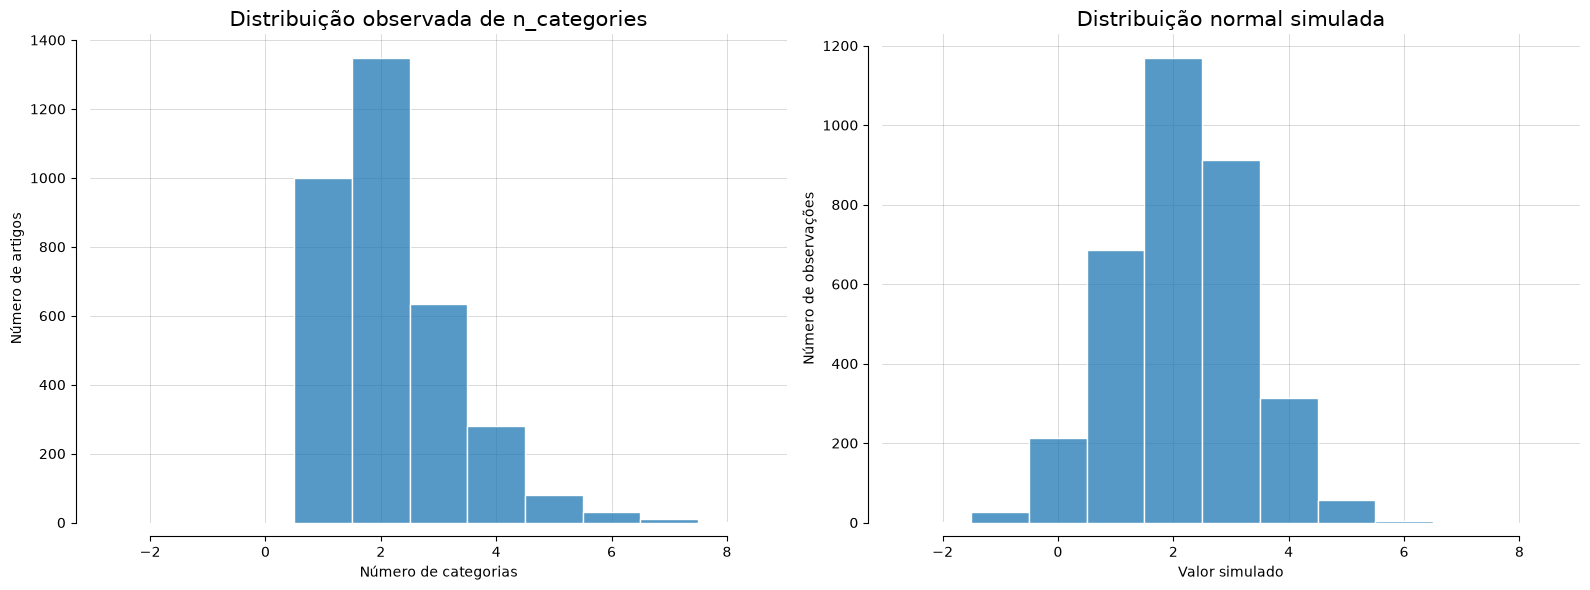

In [17]:
combined_min = min(
    arxiv_df["n_categories"].min(),
    normal_df["value"].min(),
)

combined_max = max(
    arxiv_df["n_categories"].max(),
    normal_df["value"].max(),
)

bin_edges = np.arange(
    np.floor(combined_min) - 0.5,
    np.ceil(combined_max) + 1.5,
    1,
)

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharex=True,
)

sns.histplot(
    data=arxiv_df,
    x="n_categories",
    bins=bin_edges,
    stat="count",
    edgecolor="white",
    ax=ax1,
)

ax1.set_title(
    "Distribuição observada de n_categories",
    fontsize=15,
)

ax1.set(
    xlabel="Número de categorias",
    ylabel="Número de artigos",
)

ax1.set_axisbelow(True)
ax1.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.histplot(
    data=normal_df,
    x="value",
    bins=bin_edges,
    stat="count",
    edgecolor="white",
    ax=ax2,
)

ax2.set_title(
    "Distribuição normal simulada",
    fontsize=15,
)

ax2.set(
    xlabel="Valor simulado",
    ylabel="Número de observações",
)

ax2.set_axisbelow(True)
ax2.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.despine(
    fig=fig,
    top=True,
    right=True,
    trim=True,
    offset=10,
)

plt.tight_layout()
plt.show()

A distribuição observada de `n_categories` concentra-se nos menores valores e
apresenta uma extensão assimétrica em direção às contagens maiores. A
distribuição normal simulada apresenta a forma aproximadamente simétrica
determinada por seus parâmetros.

As duas distribuições possuem centro e dispersão semelhantes por construção,
mas diferem claramente em forma e suporte. Média e desvio-padrão, portanto,
descrevem dimensões importantes da distribuição sem determinar sua estrutura
completa.

Nesta seção, a distribuição normal funciona como uma referência visual. A
relevância de pressupostos envolvendo normalidade depende do procedimento
estatístico considerado e do objeto ao qual esse pressuposto se aplica. Essa
relação será especificada quando os respectivos métodos forem introduzidos.

## 5. Função de distribuição empírica acumulada (ECDF)

A **função de distribuição empírica acumulada**, ou ECDF (*Empirical
Cumulative Distribution Function*), representa a proporção de observações com
valor menor ou igual a cada ponto da escala.

Para um valor \(x\):

$$
\widehat{F}(x)
=
\frac{
\text{número de observações com valor } \leq x
}{
n
}
$$

em que \(n\) corresponde ao número total de observações.

Para `n_categories`, por exemplo, o valor da ECDF em `2` corresponde à
proporção de artigos associados a no máximo duas categorias.

Como `n_categories` é discreta, a função cresce em degraus nos valores inteiros
observados. A altura de cada salto corresponde à proporção de artigos com
aquele número de categorias.

A ECDF representa diretamente as proporções acumuladas observadas e dispensa a
escolha de intervalos utilizada nos histogramas.

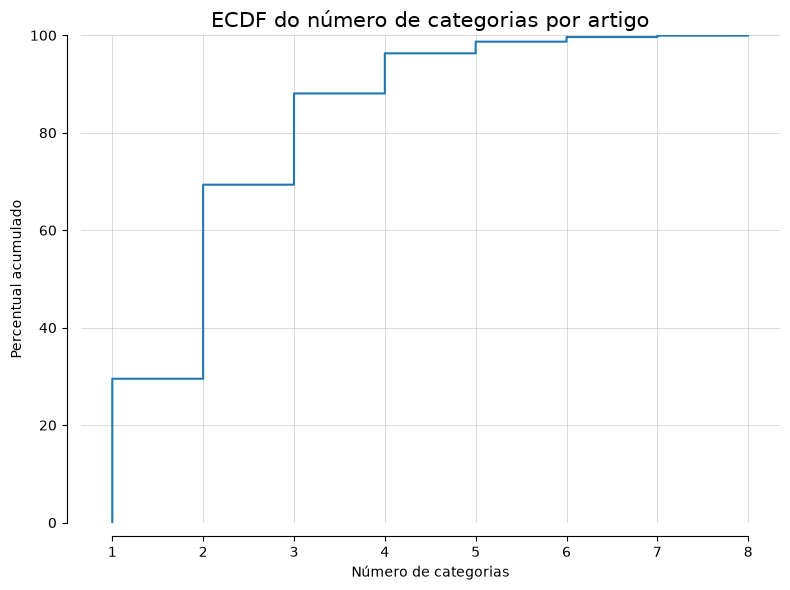

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.ecdfplot(
    data=arxiv_df,
    x="n_categories",
    stat="percent",
    ax=ax,
)

ax.set_title(
    "ECDF do número de categorias por artigo",
    fontsize=15,
)

ax.set(
    xlabel="Número de categorias",
    ylabel="Percentual acumulado",
    ylim=(0, 100),
)

category_ticks = np.arange(
    arxiv_df["n_categories"].min(),
    arxiv_df["n_categories"].max() + 1,
)

ax.set_xticks(category_ticks)

ax.set_axisbelow(True)
ax.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    trim=True,
    offset=10,
)

plt.tight_layout()
plt.show()

A ECDF permite ler diretamente percentis acumulados da distribuição. O ponto
correspondente a `2`, por exemplo, informa a proporção de artigos com uma ou
duas categorias.

Os saltos também mostram onde as observações se concentram. Um salto maior
indica que uma proporção maior dos artigos assume exatamente aquele valor.

Essa representação apresenta a distribuição por outra perspectiva: o
histograma mostra frequências locais ao longo da escala; a ECDF mostra a
proporção acumulada até cada valor.

### ECDF observada e referência normal simulada

A mesma representação pode ser aplicada à amostra normal simulada na seção
anterior.

As duas amostras possuem o mesmo número de observações e centro e dispersão
semelhantes. A comparação das ECDFs permite examinar diretamente como as
observações se acumulam ao longo de uma escala comum.

A ECDF de `n_categories` deve refletir sua natureza discreta, com saltos
concentrados nos valores inteiros. A amostra normal contém valores contínuos e
distribui seus incrementos por um número muito maior de posições na escala.

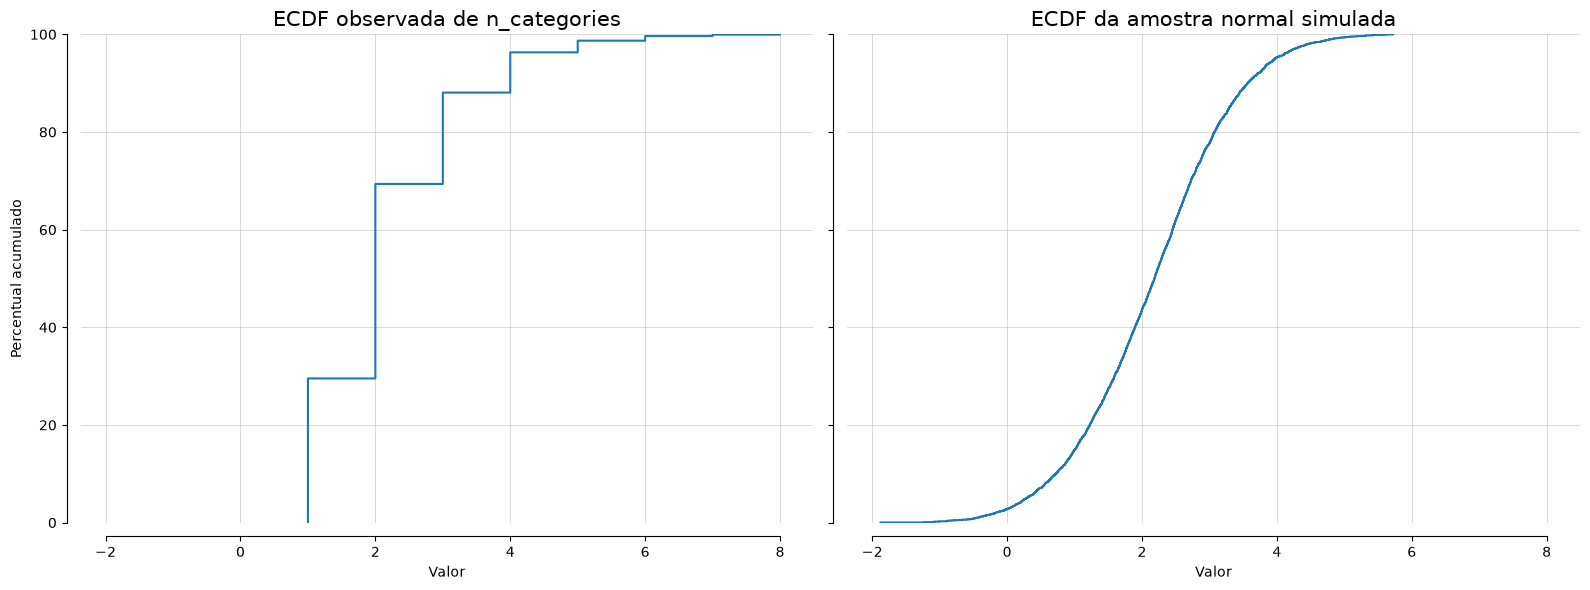

In [27]:
fig, (ax_hist, ax_ecdf) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharex=True,
    sharey=True,
)

sns.ecdfplot(
    data=arxiv_df,
    x="n_categories",
    stat="percent",
    ax=ax_hist,
)

ax_hist.set_title(
    "ECDF observada de n_categories",
    fontsize=15,
)

ax_hist.set(
    xlabel="Valor",
    ylabel="Percentual acumulado",
    ylim=(0, 100),
)

ax_hist.set_axisbelow(True)
ax_hist.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.ecdfplot(
    data=normal_df,
    x="value",
    stat="percent",
    ax=ax_ecdf,
)

ax_ecdf.set_title(
    "ECDF da amostra normal simulada",
    fontsize=15,
)

ax_ecdf.set(
    xlabel="Valor",
    ylabel="Percentual acumulado",
)

ax_ecdf.set_axisbelow(True)
ax_ecdf.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.despine(
    fig=fig,
    top=True,
    right=True,
    trim=True,
    offset=10,
)

plt.tight_layout()
plt.show()

As duas ECDFs acumulam probabilidade de maneiras distintas. Em `n_categories`,
a função apresenta saltos concentrados em poucos valores inteiros. Na amostra
normal simulada, os incrementos estão distribuídos ao longo de muitos valores
contínuos, produzindo uma curva empírica visualmente mais suave.

A diferença observada decorre da estrutura das distribuições e permanece
visível sem qualquer decisão sobre número ou largura de intervalos.

Histograma e ECDF fornecem, assim, representações complementares da mesma
distribuição. O primeiro torna frequências locais particularmente visíveis; a
segunda torna explícita a proporção acumulada abaixo de cada valor.

## 6. Tamanho da amostra e representação empírica

A amostra normal utilizada anteriormente contém 3.387 observações, o mesmo
número de artigos presente em `arxiv_df`.

Podemos manter os mesmos parâmetros da distribuição geradora - média e
desvio-padrão — e aumentar o número de observações simuladas para `100_000`.

O aumento do tamanho da amostra modifica a representação empírica da
distribuição. Com mais observações, o histograma contém mais valores em cada
região da escala e a ECDF apresenta um número muito maior de pequenos
incrementos.

Os parâmetros da distribuição geradora permanecem os mesmos. O que muda é a
quantidade de observações utilizada para representá-la.

In [23]:
normal_bigger_n = pd.DataFrame(
    {
        "value": rng.normal(
            loc=mean_categories,
            scale=std_categories,
            size=100_000,
        )
    }
)

normal_bigger_n.describe()

,value
count,100000.000000
mean,2.187555
std,1.115421
min,-3.302691
25%,1.434759
50%,2.188194
75%,2.939431
max,7.744163


A média e o desvio-padrão observados na amostra de `100_000` valores permanecem
próximos dos parâmetros utilizados na simulação.

Amostras aleatórias diferentes produzem estatísticas ligeiramente diferentes.
À medida que o tamanho da amostra aumenta, estatísticas como a média tendem a
apresentar menor variação em torno dos parâmetros da distribuição geradora.

O número de observações e a forma da distribuição são propriedades distintas.
Uma amostra maior representa com maior resolução a distribuição da qual foi
gerada.

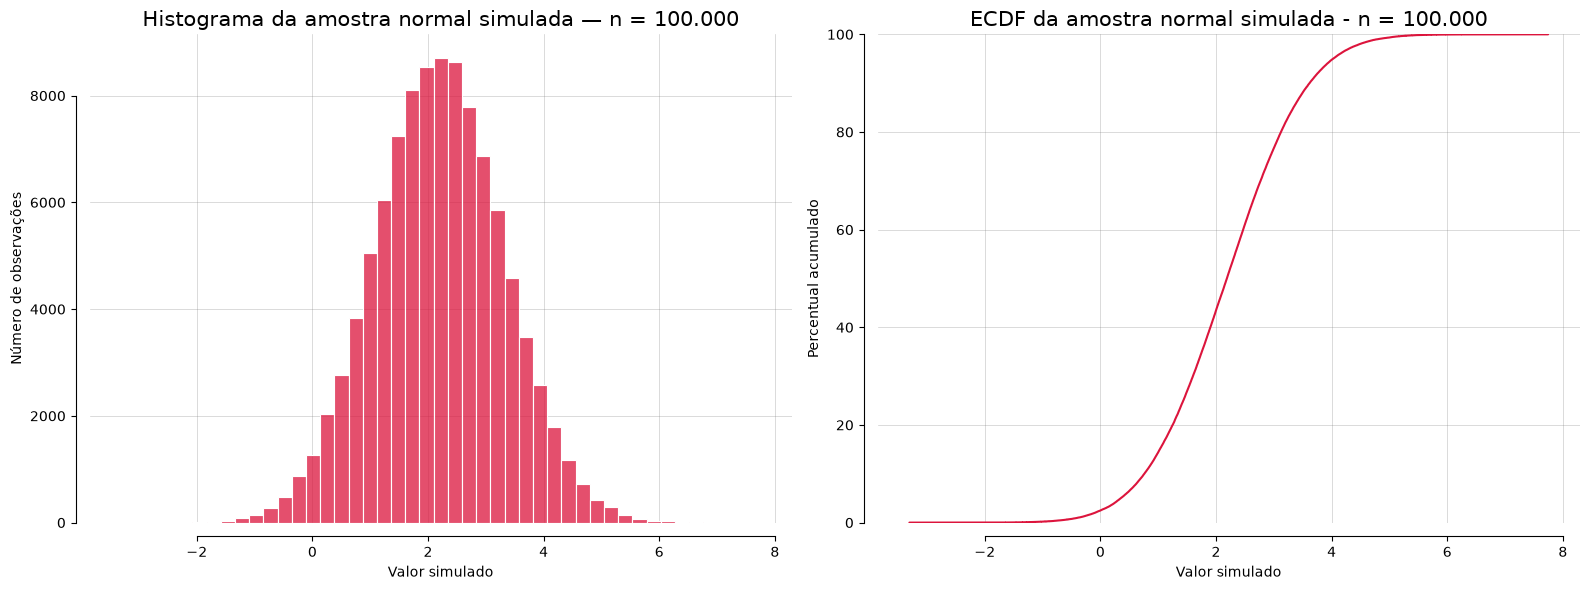

In [ ]:
fig, (ax_hist, ax_ecdf) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharex=True,
)

sns.histplot(
    data=normal_bigger_n,
    x="value",
    bins=45,
    stat="count",
    color="crimson",
    edgecolor="white",
    ax=ax_hist,
)

ax_hist.set_title(
    "Histograma da amostra normal simulada - n = 100.000",
    fontsize=15,
)

ax_hist.set(
    xlabel="Valor simulado",
    ylabel="Número de observações",
)

ax_hist.set_axisbelow(True)
ax_hist.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.ecdfplot(
    data=normal_bigger_n,
    x="value",
    stat="percent",
    color="crimson",
    ax=ax_ecdf,
)

ax_ecdf.set_title(
    "ECDF da amostra normal simulada - n = 100.000",
    fontsize=15,
)

ax_ecdf.set(
    xlabel="Valor simulado",
    ylabel="Percentual acumulado",
    ylim=(0, 100),
)

ax_ecdf.set_axisbelow(True)
ax_ecdf.grid(
    True,
    alpha=0.4,
    linewidth=0.5,
    color="grey",
)

sns.despine(
    fig=fig,
    top=True,
    right=True,
    trim=True,
    offset=10,
)

plt.tight_layout()
plt.show()

Com `100_000` observações, a forma da distribuição geradora aparece com maior
regularidade no histograma. A ECDF contém `100_000` incrementos e, por isso,
aproxima visualmente uma curva contínua, embora continue sendo uma função
empírica em degraus.

O histograma permanece dependente da definição dos intervalos. O aumento do
tamanho da amostra reduz a irregularidade decorrente da amostragem, mas a
representação gráfica continua envolvendo escolhas analíticas.

Tamanho da amostra e forma da distribuição devem ser tratados separadamente.
Uma amostra grande de uma distribuição assimétrica representará essa assimetria
com maior precisão; uma amostra grande de uma distribuição multimodal
representará seus múltiplos modos com maior precisão.

Neste encontro, centro, dispersão, forma da distribuição, representação gráfica
e tamanho da amostra foram examinados como propriedades relacionadas, mas
distintas. A escolha dos resumos e das representações depende da estrutura dos
dados e da pergunta estatística considerada.